In [ ]:
from pathlib import Path

import torch

from spd.data_utils import DatasetGeneratedDataLoader, SparseFeatureDataset
from spd.experiments.resid_mlp.resid_mlp_dataset import ResidualMLPDataset
from spd.grouping import collect_coactivations, plot_clustering_from_results, run_decomp_pipeline
from spd.models.component_model import ComponentModel
from spd.utils import get_device

# warnings.filterwarnings("ignore")

DEVICE = get_device()
print(f"Using device: {DEVICE = }")
torch.set_grad_enabled(False)

Using device: DEVICE = 'cuda'


# TMS + identity

ComponentModel(
  (model): TMSModel(
    (linear1): Linear(in_features=40, out_features=10, bias=False)
    (linear2): Linear(in_features=10, out_features=40, bias=True)
    (hidden_layers): ModuleList(
      (0): Linear(in_features=10, out_features=10, bias=False)
    )
  )
  (components): ModuleDict(
    (linear1): LinearComponent()
    (linear2): LinearComponent()
  )
  (gates): ModuleDict(
    (linear1): GateMLP()
    (linear2): GateMLP()
  )
)
TMSModel(
  (linear1): Linear(in_features=40, out_features=10, bias=False)
  (linear2): Linear(in_features=10, out_features=40, bias=True)
  (hidden_layers): ModuleList(
    (0): Linear(in_features=10, out_features=10, bias=False)
  )
)


Number of alive elements: 78
Number of clusters: 40
Cluster sizes: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 1 2
 2 2 2]


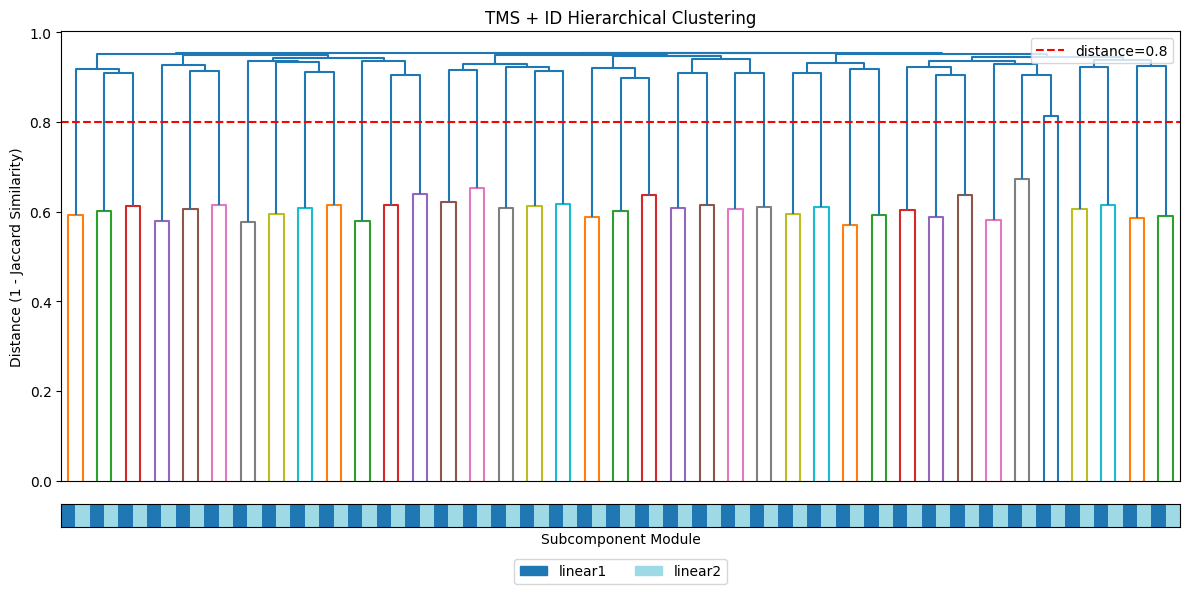

In [2]:
run_decomp_pipeline(
    model_path=Path("data/tms-decomp/model_40000.pth"),
    dataset_cls=SparseFeatureDataset,
    dataset_kwargs=dict(
        value_range=(0.0, 1.0),
        synced_inputs=None,
    ),
    coactivations_kwargs=dict(
        module_groups=[["linear1", "linear2"]],
    ),
    plot_kwargs=dict(
        group_key="group_0",
        threshold=0.8,
        title="TMS + ID Hierarchical Clustering",
        min_alive_counts=500,
    ),
    device=DEVICE,
)

# 1 layer residual MLP

ComponentModel(
  (model): ResidualMLP(
    (layers): ModuleList(
      (0): MLP(
        (mlp_in): Linear(in_features=1000, out_features=50, bias=False)
        (mlp_out): Linear(in_features=50, out_features=1000, bias=False)
      )
    )
  )
  (components): ModuleDict(
    (layers-0-mlp_in): LinearComponent()
    (layers-0-mlp_out): LinearComponent()
  )
  (gates): ModuleDict(
    (layers-0-mlp_in): GateMLP()
    (layers-0-mlp_out): GateMLP()
  )
)
ResidualMLP(
  (layers): ModuleList(
    (0): MLP(
      (mlp_in): Linear(in_features=1000, out_features=50, bias=False)
      (mlp_out): Linear(in_features=50, out_features=1000, bias=False)
    )
  )
)


Number of alive elements: 150
Number of clusters: 101
Cluster sizes: [50  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1]


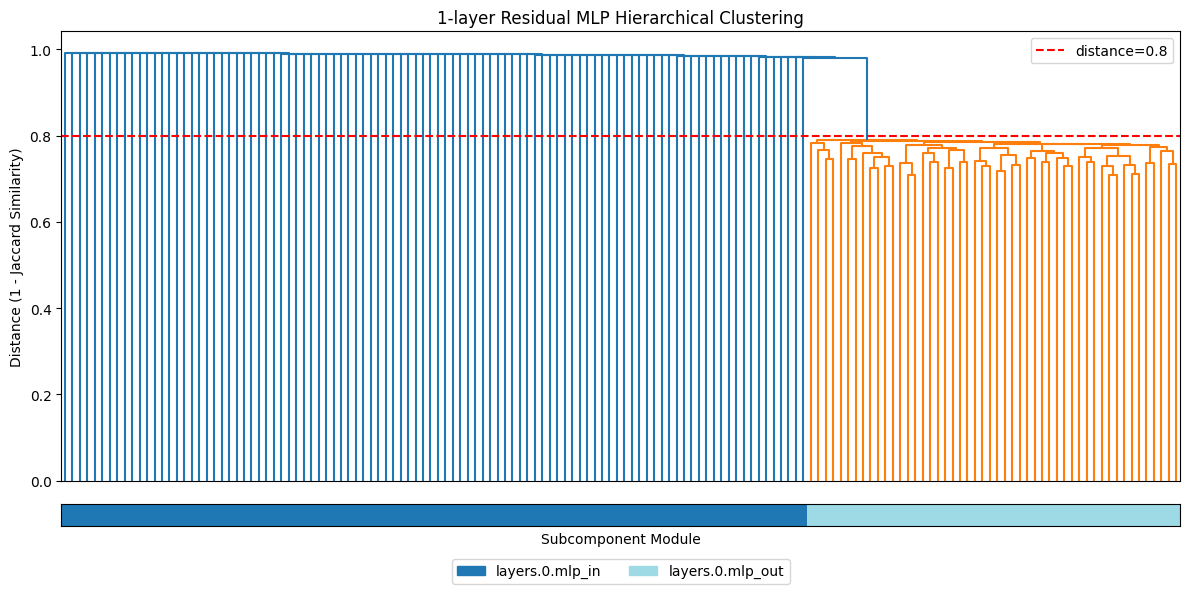

In [3]:
run_decomp_pipeline(
    model_path=Path("data/mlp-decomp/model_30000.pth"),
    dataset_cls=ResidualMLPDataset,
    dataset_kwargs=dict(
        calc_labels=False,  # Our labels will be the output of the target model
        label_type=None,
        act_fn_name=None,
        label_fn_seed=None,
        label_coeffs=None,
        synced_inputs=None,
    ),
    coactivations_kwargs=dict(
        module_groups=[["layers.0.mlp_in", "layers.0.mlp_out"]],
    ),
    plot_kwargs=dict(
        group_key="group_0",
        threshold=0.8,
        title="1-layer Residual MLP Hierarchical Clustering",
        min_alive_counts=500,
    ),
    device=DEVICE,
)

# 3 layer residual MLP

In [ ]:
MODEL_PATH = "/nlp/scr/nathu/apd/resid_mlp/out/randrecon1.00e+00_p2.00e+00_lpsp5.00e-06_m400_sd1_lr1.00e-03_bs2048_gtscaled_sigmoid_gate_mlp_ft102_lay3_resid1000_mlp17_20250620_160724_714/model_120000.pth"
# Load the decomposition model
comp_model, config, _ = ComponentModel.from_pretrained(MODEL_PATH)
comp_model.to(DEVICE)
target_model = comp_model.model


dataset = ResidualMLPDataset(
    n_features=target_model.config.n_features,
    feature_probability=config.task_config.feature_probability,
    device=DEVICE,
    calc_labels=False,  # Our labels will be the output of the target model
    label_type=None,
    act_fn_name=None,
    label_fn_seed=None,
    label_coeffs=None,
    data_generation_type=config.task_config.data_generation_type,
    synced_inputs=None,
)
data_loader = DatasetGeneratedDataLoader(
    dataset=dataset,
    batch_size=1000,
    shuffle=False,
)

FileNotFoundError: [Errno 2] No such file or directory: '/nlp/scr/nathu/apd/resid_mlp/out/randrecon1.00e+00_p2.00e+00_lpsp5.00e-06_m400_sd1_lr1.00e-03_bs2048_gtscaled_sigmoid_gate_mlp_ft102_lay3_resid1000_mlp17_20250620_160724_714/model_120000.pth'

In [ ]:
results = collect_coactivations(
    comp_model=comp_model,
    data_loader=data_loader,
    module_groups=[
        [
            "layers.0.mlp_in",
            "layers.0.mlp_out",
            "layers.1.mlp_in",
            "layers.1.mlp_out",
            "layers.2.mlp_in",
            "layers.2.mlp_out",
        ]
    ],
    n_samples=500000,
    activation_threshold=0.1,
)

In [ ]:
fig, clusters, Z, alive_mask = plot_clustering_from_results(
    results,
    group_key="group_0",
    linkage_method="average",  # complete
    threshold=0.8,
    title="3-layer Residual MLP Hierarchical Clustering",
    min_alive_counts=500,
    figsize=(15, 6),
)

In [ ]:
import pandas as pd

submodules = results["group_0"]["labels"][alive_mask]
# Get top 10 clusters by size
cluster_sizes = pd.Series(clusters).value_counts()

for cluster_id in cluster_sizes.index[0::10]:
    cluster_mask = clusters == cluster_id
    submodule_counts = pd.Series(submodules[cluster_mask]).value_counts()

    print(f"\nCluster {cluster_id} ({cluster_sizes[cluster_id]} elements):")
    for submodule, count in submodule_counts.items():
        print(f"  {submodule}: {count}")

In [ ]:
fig, clusters, Z, alive_mask = plot_clustering_from_results(
    results,
    group_key="group_0",
    linkage_method="complete",
    threshold=0.85,
    title="3-layer Residual MLP Hierarchical Clustering",
    min_alive_counts=500,
    figsize=(15, 6),
)